# 2D numerical experiment of the inverted pendulum

In [1]:
import gpytorch
import torch
from src.TVBO import TimeVaryingBOModel
from src.objective_functions_LQR import lqr_objective_function_2D

### Hyperparameters

In [2]:
# parameters regarding the objective function
objective_function_options = {'objective_function': lqr_objective_function_2D,

                              # optimize the last two entries of the feedback gain
                              'spatio_dimensions': 2,

                              # approximate noise level from the objective function
                              'noise_lvl': 0.005,

                              # feasible set for the optimization
                              'feasible_set': torch.tensor([[-62.5, -5], [-12.5, -1]],
                                                           dtype=torch.float),

                              # initial feasible set consisting of only controllers
                              'initial_feasible_set': torch.tensor([[-50, -4], [-25, -2]],
                                                                   dtype=torch.float),

                              # scaling \theta to have approximately equal lengthscales in each dimension
                              'scaling_factors': torch.tensor([3, 1 / 4])}

# parameters regarding the model
model_options = {'constrained_dimensions': None,  # later specified for each variation
                 'forgetting_type': None,  # later specified for each variation
                 'forgetting_factor': None,  # later specified for each variation

                 # specification for the constraints  (cf. Agrell 2019)
                 'nr_samples': 10000,
                 'xv_points_per_dim': 4,  # VOPs per dimensions
                 'truncation_bounds': [0, 2],

                 # specification of prior
                 'prior_mean': 0.,
                 'lengthscale_constraint': gpytorch.constraints.Interval(0.5, 6),
                 'lengthscale_hyperprior': gpytorch.priors.GammaPrior(6, 1 / 0.3),
                 'outputscale_constraint_spatio': gpytorch.constraints.Interval(0, 20),
                 'outputscale_hyperprior_spatio': None, }

### Specify variations

In [3]:
# UI -> UI-TVBO, B2P_OU -> TV-GP-UCB
variations = [
    # in the paper color green
    {'forgetting_type': 'UI', 'forgetting_factor': 0.03, 'constrained_dims': [0, 1]},

    # in the paper color blue
    {'forgetting_type': 'UI', 'forgetting_factor': 0.03, 'constrained_dims': []},

    # in the paper color purple
    {'forgetting_type': 'B2P_OU', 'forgetting_factor': 0.03, 'constrained_dims': [0, 1]},

    # in the paper color red
    {'forgetting_type': 'B2P_OU', 'forgetting_factor': 0.03, 'constrained_dims': []}, ]

### Start optimization

In [4]:
trials_per_variation = 1  # number of different runs
for variation in variations:

    # update variation specific parameters
    model_options['forgetting_type'] = variation['forgetting_type']
    model_options['forgetting_factor'] = variation['forgetting_factor']
    model_options['constrained_dimensions'] = variation['constrained_dims']

    tvbo_model = TimeVaryingBOModel(objective_function_options=objective_function_options,
                                    model_options=model_options,
                                    post_processing_options={},
                                    add_noise=False, )  # noise is added during the simulation of the pendulum

    # specify name to safe results
    method_name = model_options['forgetting_type']
    forgetting_factor = model_options['forgetting_factor']
    string = 'constrained' if model_options['constrained_dimensions'] else 'unconstrained'
    NAME = f"{method_name}_2DLQR_{string}_forgetting_factor_{forgetting_factor}".replace('.', '_')

    # run optimization
    for trial in range(1, trials_per_variation + 1):
        tvbo_model.run_TVBO(n_initial_points=30,
                            time_horizon=300,
                            safe_name=NAME,
                            trial=trial, )
    print('Finished.')

Initialization


/Users/zhangzhi/opt/anaconda3/lib/python3.9/site-packages/botorch/fit.py:143: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  /Users/distiller/project/pytorch/aten/src/ATen/native/TensorShape.cpp:2228.)
  warnings.warn(w.message, w.category)


Time for optimizing aquisition functions: 0.117s.

Timestep   30 of Trail  1.
Parameter name: noise value = 0.000
Parameter name: outputscale value = 1.000
Parameter name: lengthscale 0 value = 3.564
Parameter name: lengthscale 1 value = 3.921
Start minimax algorithm (Python implementation) for 10000 samples (D=32)...
Time taken for 10000 samples: 0.45s.
Time for optimizing aquisition functions: 0.679s.
Time for optimizing aquisition functions: 0.151s.
Time taken for timestep   30: 0.872s.

Timestep   31 of Trail  1.
Parameter name: noise value = 0.000
Parameter name: outputscale value = 1.000
Parameter name: lengthscale 0 value = 3.235
Parameter name: lengthscale 1 value = 3.797
Start minimax algorithm (Python implementation) for 10000 samples (D=32)...
Time taken for 10000 samples: 1.14s.
Time for optimizing aquisition functions: 1.324s.
Time for optimizing aquisition functions: 0.256s.
Time taken for timestep   31: 1.657s.

Timestep   32 of Trail  1.
Parameter name: noise value = 0.

Time taken for 10000 samples: 0.28s.
Time for optimizing aquisition functions: 0.474s.
Time for optimizing aquisition functions: 0.253s.
Time taken for timestep   48: 0.837s.

Timestep   49 of Trail  1.
Parameter name: noise value = 0.000
Parameter name: outputscale value = 1.000
Parameter name: lengthscale 0 value = 2.987
Parameter name: lengthscale 1 value = 4.464
Start minimax algorithm (Python implementation) for 10000 samples (D=32)...
Time taken for 10000 samples: 0.33s.
Time for optimizing aquisition functions: 0.523s.
Time for optimizing aquisition functions: 0.259s.
Time taken for timestep   49: 0.847s.

Timestep   50 of Trail  1.
Parameter name: noise value = 0.000
Parameter name: outputscale value = 1.000
Parameter name: lengthscale 0 value = 3.007
Parameter name: lengthscale 1 value = 4.497
Start minimax algorithm (Python implementation) for 10000 samples (D=32)...
Time taken for 10000 samples: 0.32s.
Time for optimizing aquisition functions: 0.626s.
Time for optimizing aqu

Time taken for 10000 samples: 0.34s.
Time for optimizing aquisition functions: 0.495s.
Time for optimizing aquisition functions: 0.306s.
Time taken for timestep   67: 0.839s.

Timestep   68 of Trail  1.
Parameter name: noise value = 0.000
Parameter name: outputscale value = 1.000
Parameter name: lengthscale 0 value = 3.076
Parameter name: lengthscale 1 value = 4.929
Start minimax algorithm (Python implementation) for 10000 samples (D=32)...
Time taken for 10000 samples: 0.35s.
Time for optimizing aquisition functions: 0.511s.
Time for optimizing aquisition functions: 0.193s.
Time taken for timestep   68: 0.748s.

Timestep   69 of Trail  1.
Parameter name: noise value = 0.000
Parameter name: outputscale value = 1.000
Parameter name: lengthscale 0 value = 3.148
Parameter name: lengthscale 1 value = 4.957
Start minimax algorithm (Python implementation) for 10000 samples (D=32)...
Time taken for 10000 samples: 0.42s.
Time for optimizing aquisition functions: 0.594s.
Time for optimizing aqu

...

Time for optimizing aquisition functions: 0.152s.
Time for optimizing aquisition functions: 0.169s.
Time taken for timestep  197: 0.550s.

Timestep  198 of Trail  1.
Parameter name: noise value = 0.000
Parameter name: outputscale value = 1.000
Parameter name: lengthscale 0 value = 4.557
Parameter name: lengthscale 1 value = 6.000
Time for optimizing aquisition functions: 0.078s.
Time for optimizing aquisition functions: 0.201s.
Time taken for timestep  198: 0.327s.

Timestep  199 of Trail  1.
Parameter name: noise value = 0.000
Parameter name: outputscale value = 1.000
Parameter name: lengthscale 0 value = 4.560
Parameter name: lengthscale 1 value = 6.000
Time for optimizing aquisition functions: 0.169s.
Time for optimizing aquisition functions: 0.101s.
Time taken for timestep  199: 0.421s.

Timestep  200 of Trail  1.
Parameter name: noise value = 0.000
Parameter name: outputscale value = 1.000
Parameter name: lengthscale 0 value = 4.563
Parameter name: lengthscale 1 value = 6.000
Time

Time taken for timestep  222: 0.296s.

Timestep  223 of Trail  1.
Parameter name: noise value = 0.000
Parameter name: outputscale value = 1.000
Parameter name: lengthscale 0 value = 4.591
Parameter name: lengthscale 1 value = 6.000
Time for optimizing aquisition functions: 0.077s.
Time for optimizing aquisition functions: 0.093s.
Time taken for timestep  223: 0.224s.

Timestep  224 of Trail  1.
Parameter name: noise value = 0.000
Parameter name: outputscale value = 1.000
Parameter name: lengthscale 0 value = 4.595
Parameter name: lengthscale 1 value = 6.000
Time for optimizing aquisition functions: 0.109s.
Time for optimizing aquisition functions: 0.282s.
Time taken for timestep  224: 0.582s.

Timestep  225 of Trail  1.
Parameter name: noise value = 0.000
Parameter name: outputscale value = 1.000
Parameter name: lengthscale 0 value = 4.595
Parameter name: lengthscale 1 value = 6.000
Time for optimizing aquisition functions: 0.106s.
Time for optimizing aquisition functions: 0.115s.
Time

Time for optimizing aquisition functions: 0.099s.
Time for optimizing aquisition functions: 0.092s.
Time taken for timestep  247: 0.373s.

Timestep  248 of Trail  1.
Parameter name: noise value = 0.000
Parameter name: outputscale value = 1.000
Parameter name: lengthscale 0 value = 4.572
Parameter name: lengthscale 1 value = 6.000
Time for optimizing aquisition functions: 0.181s.
Time for optimizing aquisition functions: 0.185s.
Time taken for timestep  248: 0.494s.

Timestep  249 of Trail  1.
Parameter name: noise value = 0.000
Parameter name: outputscale value = 1.000
Parameter name: lengthscale 0 value = 4.572
Parameter name: lengthscale 1 value = 6.000
Time for optimizing aquisition functions: 0.082s.
Time for optimizing aquisition functions: 0.270s.
Time taken for timestep  249: 0.410s.

Timestep  250 of Trail  1.
Parameter name: noise value = 0.000
Parameter name: outputscale value = 1.000
Parameter name: lengthscale 0 value = 4.596
Parameter name: lengthscale 1 value = 6.000
Time

Time for optimizing aquisition functions: 0.175s.
Time taken for timestep  272: 0.305s.

Timestep  273 of Trail  1.
Parameter name: noise value = 0.000
Parameter name: outputscale value = 1.000
Parameter name: lengthscale 0 value = 4.639
Parameter name: lengthscale 1 value = 6.000
Time for optimizing aquisition functions: 0.092s.
Time for optimizing aquisition functions: 0.211s.
Time taken for timestep  273: 0.366s.

Timestep  274 of Trail  1.
Parameter name: noise value = 0.000
Parameter name: outputscale value = 1.000
Parameter name: lengthscale 0 value = 4.640
Parameter name: lengthscale 1 value = 6.000
Time for optimizing aquisition functions: 0.101s.
Time for optimizing aquisition functions: 0.102s.
Time taken for timestep  274: 0.258s.

Timestep  275 of Trail  1.
Parameter name: noise value = 0.000
Parameter name: outputscale value = 1.000
Parameter name: lengthscale 0 value = 4.641
Parameter name: lengthscale 1 value = 6.000
Time for optimizing aquisition functions: 0.128s.
Time

Time for optimizing aquisition functions: 0.138s.
Time taken for timestep  297: 0.557s.

Timestep  298 of Trail  1.
Parameter name: noise value = 0.000
Parameter name: outputscale value = 1.000
Parameter name: lengthscale 0 value = 4.694
Parameter name: lengthscale 1 value = 6.000
Time for optimizing aquisition functions: 0.097s.
Time for optimizing aquisition functions: 0.122s.
Time taken for timestep  298: 0.286s.

Timestep  299 of Trail  1.
Parameter name: noise value = 0.000
Parameter name: outputscale value = 1.000
Parameter name: lengthscale 0 value = 4.696
Parameter name: lengthscale 1 value = 6.000
Time for optimizing aquisition functions: 0.184s.
Time for optimizing aquisition functions: 0.144s.
Time taken for timestep  299: 0.491s.
Finished.


In [5]:
import pickle

with open('results/results_UI_2DLQR_constrained_forgetting_factor_0_03_0_03_1.pickle', 'rb') as f:
    data = pickle.load(f)

print(type(data))
print(data.keys() if isinstance(data, dict) else dir(data))

<class 'dict'>
dict_keys(['trajectory', 'f_of_x', 'start_x', 'start_y', 'stable', 'inital_data_mean_and_stdv', 'scaling_factors', 'min_trajectory', 'lengthscales', 'settings', 'virtual_obs_points'])


In [10]:
results = load_results()
for k in results.keys():
    print(repr(k))

'B2P_OU_2DLQR_constrained_forgetting_factor_0_03_0_03'
'B2P_OU_2DLQR_unconstrained_forgetting_factor_0_03_0_03'
'UI_2DLQR_constrained_forgetting_factor_0_03_0_03'
'UI_2DLQR_unconstrained_forgetting_factor_0_03_0_03'


Method                Regret mean   Regret std  Unstable mean  n_trials
------------------------------------------------------------------------
C-UI-TVBO                  527.91        53.76           0.00         2
UI-TVBO                   7008.97         0.00           3.00         1
C-TV-GP-UCB               7069.77         0.00           0.00         1
TV-GP-UCB                 7125.03         0.00          12.00         1


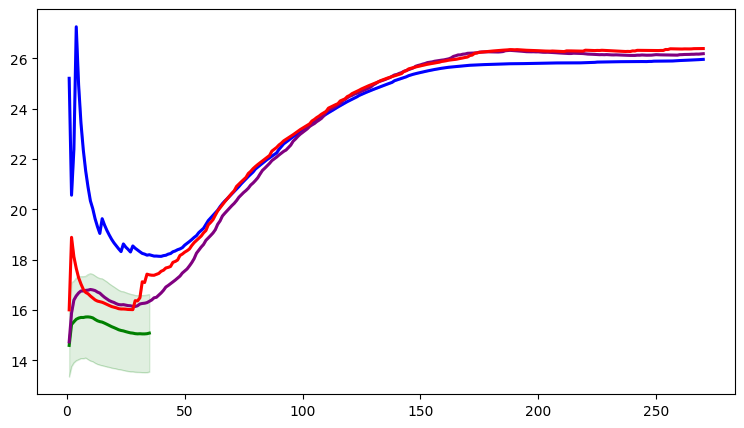

In [19]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os

def load_results(folder='results'):
    files = sorted([f for f in os.listdir(folder) if f.endswith('.pickle')])
    results = {}
    for f in files:
        with open(os.path.join(folder, f), 'rb') as fh:
            data = pickle.load(fh)
        name = f.replace('results_', '').replace('.pickle', '')
        key = '_'.join(name.split('_')[:-1])
        if key not in results:
            results[key] = []
        results[key].append(data)
    return results

def compute_regret(data):
    mean_y, std_y = data['inital_data_mean_and_stdv']
    mean_y = float(mean_y)
    std_y = float(std_y)
    f = (data['f_of_x'] - mean_y) / std_y
    f_min = data['min_trajectory']
    if hasattr(f_min, 'ndim') and f_min.ndim == 2:
        f_min = f_min[:, 0]
    f_min = (f_min - mean_y) / std_y

    n_init = len(f) - len(f_min)
    f_bo = f[n_init:]
    min_len = min(len(f_bo), len(f_min))
    f_bo = f_bo[:min_len]
    f_min = f_min[:min_len]

    regret_steps = f_bo - f_min
    regret_steps = np.maximum(regret_steps, 0)
    cumulative = np.cumsum(regret_steps)
    normalized = cumulative / (np.arange(1, min_len + 1))
    return normalized
def count_unstable(data):
    return sum(1 for s in data['stable'][30:] if not s)

results = load_results()
colors = {
    'UI_2DLQR_constrained_forgetting_factor_0_03_0_03':       ('green',  'C-UI-TVBO'),
    'UI_2DLQR_unconstrained_forgetting_factor_0_03_0_03':     ('blue',   'UI-TVBO'),
    'B2P_OU_2DLQR_constrained_forgetting_factor_0_03_0_03':   ('purple', 'C-TV-GP-UCB'),
    'B2P_OU_2DLQR_unconstrained_forgetting_factor_0_03_0_03': ('red',    'TV-GP-UCB'),
}

fig, ax = plt.subplots(figsize=(9, 5))
t = np.arange(1, 271)

print(f"{'Method':<20} {'Regret mean':>12} {'Regret std':>12} {'Unstable mean':>14} {'n_trials':>9}")
print("-" * 72)
for key, (color, label) in colors.items():
    if key not in results:
        continue
    trials = results[key]
    regrets = [compute_regret(d) for d in trials]
    
    # 统一长度，取最短的
    min_len = min(len(r) for r in regrets)
    regrets = [r[:min_len] for r in regrets]
    t = np.arange(1, min_len + 1)
    
    mean_r = np.mean(regrets, axis=0)
    std_r  = np.std(regrets, axis=0)

    for r in regrets:
        ax.plot(t, r, color=color, alpha=0.15, linewidth=0.6)
    ax.plot(t, mean_r, color=color, linewidth=2.2, label=label)
    ax.fill_between(t, mean_r - std_r, mean_r + std_r, color=color, alpha=0.12)

    unstable = [count_unstable(d) for d in trials]
    final_regret = [r[-1] * min_len for r in regrets]
    print(f"{label:<20} {np.mean(final_regret):>12.2f} {np.std(final_regret):>12.2f} "
          f"{np.mean(unstable):>14.2f} {len(trials):>9}")